In [111]:
# For WIP and avoid re-executing individual cells, to be deleted...

#import warnings
#warnings.simplefilter(action='ignore', category=FutureWarning)
#warnings.simplefilter(action='ignore', category=DeprecationWarning)
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["PL_TORCH_DISTRIBUTED_BACKEND"] = "gloo"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
#from time import time
import joblib
from pathlib import Path
#from time import time
#from tqdm import tqdm
import copy
import matplotlib as mpl
import napari
#import colorcet as cc
#import composition_stats as cs
#from sklearn.impute import KNNImputer

#from sklearn.cluster import KMeans
#from sklearn.metrics import silhouette_samples, silhouette_score
#import matplotlib.cm as cm

from tysserand import tysserand as ty
from mosna import mosna

import matplotlib as mpl

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
#from phenograph.cluster import cluster
import glob
from pathlib import Path
from tqdm import tqdm
import json
import numpy as np
import os, random
from scipy.stats import zscore

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

Calcul des statistiques autour de chaque nodes

In [154]:
nodes_dir = Path('./data/nodes_arcsinh_states_labeled/corrected_double_status_tumour_and_macrostates_labeled/leiden_states')
edges_dir = Path('./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/edges_tysserand')
#net_dir = Path('./OUTPUT_arcsinh/nodes_et_edges')
stat_funcs='default'
stat_names='default'
method = 'NAS'

                 

In [155]:
nodes = pd.read_parquet(nodes_dir / 'nodes_patient-1_sample-1.parquet')
cols = nodes.iloc[:,11:]

print(nodes.columns)
cols

Index(['Object', 'Phenotype', 'area', 'centroid-0', 'centroid-1',
       'axis_major_length', 'axis_minor_length', 'eccentricity', 'Macro_label',
       'double_status', 'cell_id', '89Y-Collagen-I', '142Nd-CA9',
       '143Nd-Vimentin', '144Nd-CD14', '145Nd-CD31', '146Nd-CD11b',
       '147Sm-CD163', '148Nd-Pan-Keratin', '149Sm-CD15', '150Nd-CD274',
       '151Eu-LYVE1', '153Eu-CD16', '154Sm-CD11c', '155Gd-FoxP3', '156Gd-CD4',
       '158Gd-E-Cadherin', '159Tb-CD68', '160Gd-FAP', '161Dy-CD20',
       '162Dy-CD8a', '163Dy-CD206', '164Dy-KRT17', '166Er-CD74',
       '167Er-Granzyme_B', '168Er-Ki-67', '169Tm-FOLR2', '170Er-CD3',
       '171Yb-MS4A4A', '172Yb-S100A2', '173Yb-CD45RO', '174Yb-Keratin_8_18',
       '176Yb-Histone_H3', '191Ir-DNA1', '193Ir-DNA2', '195Pt-ICSK1',
       '196Pt-ICSK2', '198Pt-ICSK3', '209Bi-aSMA'],
      dtype='object')


,89Y-Collagen-I,142Nd-CA9,143Nd-Vimentin,144Nd-CD14,145Nd-CD31,146Nd-CD11b,147Sm-CD163,148Nd-Pan-Keratin,149Sm-CD15,150Nd-CD274,...,172Yb-S100A2,173Yb-CD45RO,174Yb-Keratin_8_18,176Yb-Histone_H3,191Ir-DNA1,193Ir-DNA2,195Pt-ICSK1,196Pt-ICSK2,198Pt-ICSK3,209Bi-aSMA
0,0.00000,0.721856,0.568825,0.473507,0.0,0.0,0.00000,0.278198,0.0,0.0,...,0.0,0.000000,0.00000,1.500646,0.253864,0.390035,1.205476,1.772559,2.463473,0.360163
1,0.00000,0.000000,0.426181,0.198690,0.0,0.0,0.00000,0.000000,0.0,0.0,...,0.0,0.000000,0.00000,0.980150,0.825277,1.083076,0.000000,0.396342,0.202807,1.144475
2,0.00000,0.983697,0.322196,0.198690,0.0,0.0,0.00000,0.390035,0.0,0.0,...,0.0,0.000000,0.00000,1.353835,1.234049,1.575688,0.872721,1.227807,2.046554,0.390035
3,0.00000,0.000000,0.319249,0.198690,0.0,0.0,0.00000,0.000000,0.0,0.0,...,0.0,0.000000,0.00000,1.460546,0.862296,1.325104,0.198690,0.099834,0.248824,0.597676
4,0.00000,0.000000,0.226849,0.198690,0.0,0.0,0.00000,0.000000,0.0,0.0,...,0.0,0.000000,0.00000,1.205257,1.157815,1.661765,0.000000,0.270104,0.365226,1.238442
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9487,0.00000,1.213585,0.260929,0.295673,0.0,0.0,0.00000,0.232597,0.0,0.0,...,0.0,0.000000,0.00000,1.025922,0.000000,0.658800,0.634385,1.390194,2.351077,0.459824
9488,0.00000,1.360883,0.405219,0.275502,0.0,0.0,0.00000,0.674322,0.0,0.0,...,0.0,0.000000,0.19869,1.227699,0.213377,0.895445,0.412041,1.076987,2.316197,0.198690
9489,0.00000,0.198690,0.364008,0.099834,0.0,0.0,0.00000,0.000000,0.0,0.0,...,0.0,0.099834,0.00000,1.150300,0.403926,1.118768,0.000000,0.000000,0.369719,1.493315
9490,0.00000,0.575075,0.101923,0.295673,0.0,0.0,0.00000,0.137368,0.0,0.0,...,0.0,0.000000,0.00000,2.249840,2.036570,2.342868,0.291744,0.198690,1.188256,1.197478


In [156]:
use_attributes = nodes.columns[11:]
print(len(use_attributes))
use_attributes

38


Index(['89Y-Collagen-I', '142Nd-CA9', '143Nd-Vimentin', '144Nd-CD14',
       '145Nd-CD31', '146Nd-CD11b', '147Sm-CD163', '148Nd-Pan-Keratin',
       '149Sm-CD15', '150Nd-CD274', '151Eu-LYVE1', '153Eu-CD16', '154Sm-CD11c',
       '155Gd-FoxP3', '156Gd-CD4', '158Gd-E-Cadherin', '159Tb-CD68',
       '160Gd-FAP', '161Dy-CD20', '162Dy-CD8a', '163Dy-CD206', '164Dy-KRT17',
       '166Er-CD74', '167Er-Granzyme_B', '168Er-Ki-67', '169Tm-FOLR2',
       '170Er-CD3', '171Yb-MS4A4A', '172Yb-S100A2', '173Yb-CD45RO',
       '174Yb-Keratin_8_18', '176Yb-Histone_H3', '191Ir-DNA1', '193Ir-DNA2',
       '195Pt-ICSK1', '196Pt-ICSK2', '198Pt-ICSK3', '209Bi-aSMA'],
      dtype='object')

In [115]:
folder_directory = "./arcsinh/Steinbock/"
morphology_path = Path('./arcsinh/Steinbock/regionprops')

folder_saving = Path(folder_directory) / "Figures"
folder_saving.mkdir(exist_ok=True)

WHOLE_SAMPLE = True
LOAD_DATA = False


RUN_PHENOGRAPH = not LOAD_DATA

folder_directory = Path(folder_directory)
marker_directory = folder_directory / "intensities"
info_path = Path(folder_directory) / "informations.json"
files = sorted(list(marker_directory.glob("*")))

with open(info_path) as f:
    data = json.load(f)

functional_markers = data["functional_markers"]
identity_markers = data["identity_markers"]
segmentation_markers = data["segmentation_markers"]

no_markers_cols = ["Object"]
all_markers = data["markers"]

assert set(identity_markers + functional_markers + segmentation_markers) == set(all_markers)

metainfo = pd.read_csv(folder_directory / "images_metadatainfo.csv")
functional_markers = ['89Y-Collagen-I',
 '142Nd-CA9',
 '143Nd-Vimentin',
 #'150Nd-CD274',
 #'151Eu-LYVE1',
 '167Er-Granzyme_B',
 '168Er-Ki-67']


In [116]:

markers_to_remove = segmentation_markers 
use_attributes = use_attributes.drop(markers_to_remove, errors="ignore")
print(len(use_attributes))
use_attributes

32


Index(['89Y-Collagen-I', '142Nd-CA9', '143Nd-Vimentin', '144Nd-CD14',
       '145Nd-CD31', '146Nd-CD11b', '147Sm-CD163', '148Nd-Pan-Keratin',
       '149Sm-CD15', '150Nd-CD274', '151Eu-LYVE1', '153Eu-CD16', '154Sm-CD11c',
       '155Gd-FoxP3', '156Gd-CD4', '158Gd-E-Cadherin', '159Tb-CD68',
       '160Gd-FAP', '161Dy-CD20', '162Dy-CD8a', '163Dy-CD206', '164Dy-KRT17',
       '166Er-CD74', '167Er-Granzyme_B', '168Er-Ki-67', '169Tm-FOLR2',
       '170Er-CD3', '171Yb-MS4A4A', '172Yb-S100A2', '173Yb-CD45RO',
       '174Yb-Keratin_8_18', '209Bi-aSMA'],
      dtype='object')

In [158]:
# stats des neighbours autour d'un node
nodes_dir = Path('./data/nodes_arcsinh_states_labeled/corrected_double_status_tumour_and_macrostates_labeled/leiden_states')
edges_dir = Path('./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/edges_tysserand')
stat_funcs='default'
stat_names='default'
method = 'NAS'
id_level_1 = 'patient'
id_level_2 = 'sample'
col_coords = ["centroid-1", "centroid-0"]
attributes_col = nodes.columns
use_attributes = use_attributes
make_onehot = False
data_info = ['1','1']
read_fct = pd.read_parquet
extension = 'parquet'
parallel_groups = 25
memory_limit = '20GB'

var_aggreg = mosna.compute_spatial_omic_features_all_networks(method=method,attributes_col= attributes_col, use_attributes= use_attributes, stat_funcs=stat_funcs,stat_names=stat_names, extension =extension,nodes_dir=nodes_dir, edges_dir=edges_dir, id_level_1 = id_level_1, id_level_2 =id_level_2, make_onehot = make_onehot,parallel_groups = parallel_groups, memory_limit = memory_limit)

#enregistrer
save_dir = Path("./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/niches/agreg")
save_dir.mkdir(parents=True, exist_ok=True)
filename = save_dir / f'aggregation_statistics_new.parquet'
var_aggreg.to_parquet(filename, index=False)
                                             

In [159]:
#récup les stats dans un fichier sans cacluler dans fichier
file_name = 'aggregation_statistics_new.parquet'
save_dir = Path("./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/niches/agreg")
var_aggreg = pd.read_parquet(save_dir / file_name)



In [160]:
var_aggreg

,89Y-Collagen-I mean,142Nd-CA9 mean,143Nd-Vimentin mean,144Nd-CD14 mean,145Nd-CD31 mean,146Nd-CD11b mean,147Sm-CD163 mean,148Nd-Pan-Keratin mean,149Sm-CD15 mean,150Nd-CD274 mean,...,174Yb-Keratin_8_18 std,176Yb-Histone_H3 std,191Ir-DNA1 std,193Ir-DNA2 std,195Pt-ICSK1 std,196Pt-ICSK2 std,198Pt-ICSK3 std,209Bi-aSMA std,patient,sample
0,0.066230,0.0,0.176723,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,...,0.0,0.304473,0.442215,0.727038,0.083407,0.200201,0.083415,0.218518,4,1
1,0.084639,0.0,0.494123,0.114760,0.000000,0.000000,0.0,0.0,0.0,0.000000,...,0.0,0.374713,0.496643,0.566627,0.211546,0.232745,0.080795,0.242566,4,1
2,0.054291,0.0,0.448971,0.059705,0.000000,0.000000,0.0,0.0,0.0,0.039738,...,0.0,0.315810,0.404026,0.459941,0.274228,0.469487,0.062941,0.552917,4,1
3,0.099508,0.0,0.310235,0.011464,0.000000,0.000000,0.0,0.0,0.0,0.066230,...,0.0,0.409938,0.091490,0.217953,0.088849,0.047062,0.043459,0.119155,4,1
4,0.000000,0.0,0.332807,0.019967,0.032457,0.000000,0.0,0.0,0.0,0.000000,...,0.0,0.306246,0.343657,0.245957,0.126663,0.176397,0.046042,0.109647,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
543082,0.000000,0.0,0.469954,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,...,0.0,0.533315,0.168969,0.272579,0.127841,0.064994,0.081186,0.110283,1,3
543083,0.000000,0.0,0.248618,0.141844,0.000000,0.014308,0.0,0.0,0.0,0.000000,...,0.0,0.537615,0.233091,0.232650,0.221022,0.176234,0.084735,0.358449,1,3
543084,0.000000,0.0,0.360891,0.016639,0.000000,0.000000,0.0,0.0,0.0,0.000000,...,0.0,0.377009,0.252041,0.419717,0.179348,0.146411,0.143670,0.289903,1,3
543085,0.000000,0.0,0.387373,0.016639,0.000000,0.000000,0.0,0.0,0.0,0.000000,...,0.0,0.550139,0.145981,0.350982,0.139784,0.125724,0.096502,0.400512,1,3


In [161]:
#on récupère var aggreg clean et samples_info pour la suite
#var_aggreg_clean = var_aggreg.dropna()
#var_aggreg_samples_info = var_aggreg_clean[['patient', 'sample']]
var_aggreg_samples_info = var_aggreg[['patient', 'sample']].copy()

Cell types : allignement des cell types dans un array avec le même ordre que nodes respectifs dans var_aggreg

description de la fonction utilisée mosna.aggregate_cell_types:
Aggregate cell types in the same order of patients and samples IDs as for the Neighbors Aggregation Statistics method.

In [162]:
#je récupère les cell_type de base


folder = Path("./data/nodes_arcsinh_states_labeled/corrected_double_status_tumour_and_macrostates_labeled/leiden_states")
files = folder.glob("nodes_*")


all_dfs = []

for file in files:
    
    if "nodes" not in file.name:
        continue

    if file.suffix == ".csv":
        df = pd.read_csv(file)
    elif file.suffix == ".parquet":
        df = pd.read_parquet(file)
    elif file.suffix in [".xlsx", ".xls"]:
        df = pd.read_excel(file)
    else:
        continue

    df["source_file"] = file.stem
    all_dfs.append(df)

big_nodes = pd.concat(all_dfs, ignore_index=True)

In [163]:
big_nodes

,Object,Phenotype,area,centroid-0,centroid-1,axis_major_length,axis_minor_length,eccentricity,Macro_label,double_status,...,173Yb-CD45RO,174Yb-Keratin_8_18,176Yb-Histone_H3,191Ir-DNA1,193Ir-DNA2,195Pt-ICSK1,196Pt-ICSK2,198Pt-ICSK3,209Bi-aSMA,source_file
0,1,CAF,15,0.800000,307.600000,6.342285,2.973565,0.883279,NaN,None,...,0.000000,0.0,0.000000,0.198690,0.000000,0.140537,0.565220,0.232305,1.637157,nodes_patient-4_sample-1
1,2,Unknown,7,0.428571,589.714286,4.155375,1.905471,0.888666,NaN,None,...,0.000000,0.0,0.884058,1.298791,1.852792,0.198690,0.198690,0.368035,0.287042,nodes_patient-4_sample-1
2,3,B Cell,8,0.500000,602.500000,4.472136,2.000000,0.894427,NaN,None,...,0.000000,0.0,0.815764,0.704468,1.350926,0.749755,0.834438,0.499649,0.791222,nodes_patient-4_sample-1
3,4,CAF,18,0.888889,1159.166667,7.086920,3.235263,0.889717,NaN,None,...,0.000000,0.0,0.839543,0.588447,1.092759,0.213573,0.099834,0.304187,0.401893,nodes_patient-4_sample-1
4,5,DC,6,0.500000,1324.000000,3.265986,2.000000,0.790569,NaN,None,...,0.123784,0.0,0.788060,0.554279,1.595580,0.312299,0.273286,0.290593,0.000000,nodes_patient-4_sample-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
543082,11150,CAF,6,1087.500000,1741.000000,3.265986,2.000000,0.790569,NaN,None,...,0.000000,0.0,0.705739,0.365507,0.490762,0.000000,0.551859,0.238532,1.287768,nodes_patient-1_sample-3
543083,11151,Epithelial Cell,14,1087.071429,1908.142857,5.449354,3.145851,0.816540,NaN,None,...,0.000000,0.0,1.874631,0.541018,0.566079,0.670840,0.800594,0.391984,0.397638,nodes_patient-1_sample-3
543084,11152,Unknown,9,1087.555556,50.777778,5.274258,1.946056,0.929440,NaN,None,...,0.607027,0.0,0.488356,0.411120,0.387063,0.450415,0.592178,0.439148,1.396134,nodes_patient-1_sample-3
543085,11153,CAF,4,1087.500000,219.500000,2.000000,2.000000,0.000000,NaN,None,...,0.099834,0.0,0.852805,0.749137,0.529857,0.099834,0.198690,0.105405,0.507706,nodes_patient-1_sample-3


In [164]:
#Aggregate cell types in the same order of patients and samples IDs as for the Neighbors Aggregation Statistics method.

# à partir de colonne source_file, créé colonne patient et sample
big_nodes[["patient", "sample"]] = big_nodes["source_file"].str.extract(
    r"patient-(\d+)_sample-(\d+)"
).copy()

big_nodes["patient"] = big_nodes["patient"].astype(int)
big_nodes["sample"] = big_nodes["sample"].astype(int)

#données pour la fonction mosna.aggregate_cell_types
cohort_data = big_nodes 
pheno_col = 'Phenotype'
patient_col = 'patient'
sample_col = 'sample'
file_name = "cell_types_aggreg_good_order.parquet"
save_dir = Path("./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/niches/agreg")

# je mets en int car dans big_nodes c'est en int
var_aggreg_samples_info[patient_col] = var_aggreg_samples_info[patient_col].astype(int)
var_aggreg_samples_info[sample_col] = var_aggreg_samples_info[sample_col].astype(int)


#renvoie array avec les cell type allignés 
cell_types = mosna.aggregate_cell_types(
    var_aggreg_samples_info = var_aggreg_samples_info,
    cohort_data = cohort_data,
    pheno_col = pheno_col,
    patient_col = patient_col,
    sample_col = sample_col,
    save_data = True,
    file_name = file_name,
    nodes_dir = save_dir,
    force_recompute = True
    )

Aggregating cell types in correct order


43it [00:00, 1065.02it/s]

Concatenated 543087 cells


Réduction et clustering

In [165]:

#Pour le clustering 



cluster_params = {
    'reducer_type' : 'umap',
   'clusterer_type':'leiden',
   'n_clusters':7,
   'force_recompute' : False,
   'resolution' : 0.05,
   #n_neighbors = neighbors dans umap et k_cluster = neighbors dans kmm
   'n_neighbors' :20,
   'k_cluster' : 15
   #résolution que pour leiden
   
}

In [166]:
#récup les stats par nodes dans un fichier sans cacluler dans fichier
file_name = 'aggregation_statistics_new.parquet'
save_dir = Path("./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/niches/agreg")
var_aggreg = pd.read_parquet(save_dir / file_name)

#récup les cell types sans calculer si dans fichier

cell_types = np.load(save_dir / f'cell_types_aggreg_good_order.parquet.npy',allow_pickle=True)

In [167]:
#var_aggreg_clean = var_aggreg.dropna()
var_aggreg_clean = (
    var_aggreg.drop(columns=['patient', 'sample'])
)

In [168]:
#réduction et clustering 

data_dir = Path("./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/niches/results_niche/")

labels, cluster_dir, n_clust, _, = mosna.get_clusterer(
    data=var_aggreg_clean.values,
    data_dir=data_dir,
    n_neighbors = cluster_params['n_neighbors'],
    reducer_type=cluster_params['reducer_type'],
    clusterer_type=cluster_params['clusterer_type'],
    n_clusters=cluster_params['n_clusters'],
    force_recompute=cluster_params['force_recompute'],
    resolution=cluster_params['resolution'],
    k_cluster = cluster_params['k_cluster'],
    use_gpu=False
)

Computing dimensionality reduction
Performing clustering
Found 45 clusters


In [169]:


def get_reducer_dir_name(cluster_params, reducer_dir_name):
    #fonction pour récupérer le nom du dossier cluster
    #cluster_params = dico
    #reducer dir name = str
    if cluster_params["clusterer_type"] == 'leiden':
        n_neighbors = str(cluster_params["n_neighbors"])
        k_cluster = str(cluster_params["k_cluster"])
        clusterer_dir_name = f'clusterer-{cluster_params["clusterer_type"]}_n_neighbors-{k_cluster}'
    elif cluster_params["clusterer_type"] == 'spectral' or cluster_params["clusterer_type"] == 'ecg':
        k_cluster = str(cluster_params["k_cluster"])
        clusterer_dir_name = f'clusterer-{cluster_params["clusterer_type"]}_n_neighbors-{k_cluster}'
    else : 
        clusterer_dir_name = f'clusterer-{cluster_params["clusterer_type"]}'
    return clusterer_dir_name

In [170]:
reducer_dir_name = "reducer-umap_dim-2_nneigh-20_metric-manhattan_min_dist-0.0"

In [171]:
# charger les labels sans recalculer
#file name = nom du fichier avec les labels

clusterer_dir_name = get_reducer_dir_name(cluster_params, reducer_dir_name) 

labels_file_name = 'leiden_resolution-0.05_labels.npy'


chemin = f'./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/niches/results_niche/{reducer_dir_name}/{clusterer_dir_name}'
chemin = Path(chemin)
labels = np.load(chemin/labels_file_name)

In [172]:
#Enregistre (sans dropna) un data frame avec les nodes et leur label niche, index n'est pas set à zéro
#(ici mets les lignes qui recup big nodes, comme ça sera sans colone patient salmple en doukble)

clusterer_dir_name = get_reducer_dir_name(cluster_params, reducer_dir_name)
chemin = f'./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/niches/results_niche/{reducer_dir_name}/{clusterer_dir_name}/OUTPUT'
save_dir = Path(chemin)

folder = Path("./data/nodes_arcsinh_states_labeled/corrected_double_status_tumour_and_macrostates_labeled/leiden_states")
files = folder.glob("nodes_*")




all_dfs = []

for file in files:
    
    if "nodes" not in file.name:
        continue

    if file.suffix == ".csv":
        df = pd.read_csv(file)
    elif file.suffix == ".parquet":
        df = pd.read_parquet(file)
    elif file.suffix in [".xlsx", ".xls"]:
        df = pd.read_excel(file)
    else:
        continue

    df["source_file"] = file.stem
    all_dfs.append(df)



nodes_cluster_labeled = pd.concat(all_dfs, ignore_index=True)

#nodes_cluster_labeled = pd.concat([big_nodes, var_aggreg], axis=1)


#print(nodes_cluster_labeled[['patient','sample','source_file']])
#nodes_cluster_labeled = nodes_cluster_labeled.reset_index()
#supprime les colonnes en dupliqué et garde que premier qu'il rencontre
#nodes_cluster_labeled = nodes_cluster_labeled.loc[:, ~nodes_cluster_labeled.columns.duplicated()]
nodes_cluster_labeled['Niche'] = labels
print(nodes_cluster_labeled[['source_file',"Niche",'Object']])

# crée tous les dossiers parents si besoin
save_dir.mkdir(parents=True, exist_ok=True)

nodes_cluster_labeled.to_parquet(save_dir/f'nodes_cluster_{cluster_params["clusterer_type"]}_labeled.parquet')

                     source_file  Niche  Object
0       nodes_patient-4_sample-1      1       1
1       nodes_patient-4_sample-1      6       2
2       nodes_patient-4_sample-1      6       3
3       nodes_patient-4_sample-1      0       4
4       nodes_patient-4_sample-1      0       5
...                          ...    ...     ...
543082  nodes_patient-1_sample-3      1   11150
543083  nodes_patient-1_sample-3      0   11151
543084  nodes_patient-1_sample-3      1   11152
543085  nodes_patient-1_sample-3      1   11153
543086  nodes_patient-1_sample-3      1   11154

[543087 rows x 3 columns]


Génération des plots

In [173]:
reducer_dir_name ='reducer-umap_dim-2_nneigh-20_metric-manhattan_min_dist-0.0'

In [174]:

#charger les embeddings
file_name = 'embedding.npy'
path = Path("./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/niches/results_niche/",reducer_dir_name)
embed_viz = np.load(path/file_name)
embed_viz

array([[-5.5923123,  7.6615086],
       [-4.515291 ,  5.8340497],
       [-4.6535807,  5.770803 ],
       ...,
       [-4.5468397,  7.976574 ],
       [-5.2623177,  7.332421 ],
       [-5.227412 ,  7.6982956]], shape=(543087, 2), dtype=float32)

In [175]:
# charger les labels sans recalculer
#file name = nom du fichier avec les labels
clusterer_dir_name = get_reducer_dir_name(cluster_params, reducer_dir_name) 

labels_file_name = 'leiden_resolution-0.05_labels.npy'


chemin = f'./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/niches/results_niche/{reducer_dir_name}/{clusterer_dir_name}/'
chemin = Path(chemin)
labels = np.load(chemin/labels_file_name)

In [176]:
#récupérer un dico avec les params qui vont s'afficher dans nom des fichiers plots

if cluster_params['clusterer_type'] == 'gmm' or cluster_params['clusterer_type'] == 'spectral':
   cluster_params_plot = {
      'clusterer_type': cluster_params['clusterer_type'],
      'n_clusters': cluster_params['n_clusters']
   }  
elif cluster_params['clusterer_type'] == 'leiden':
   cluster_params_plot = {
      'clusterer_type': cluster_params['clusterer_type'],
      'res': str(cluster_params['resolution'])
   }
else:
   cluster_params_plot = {
      'clusterer_type': cluster_params['clusterer_type']
   }


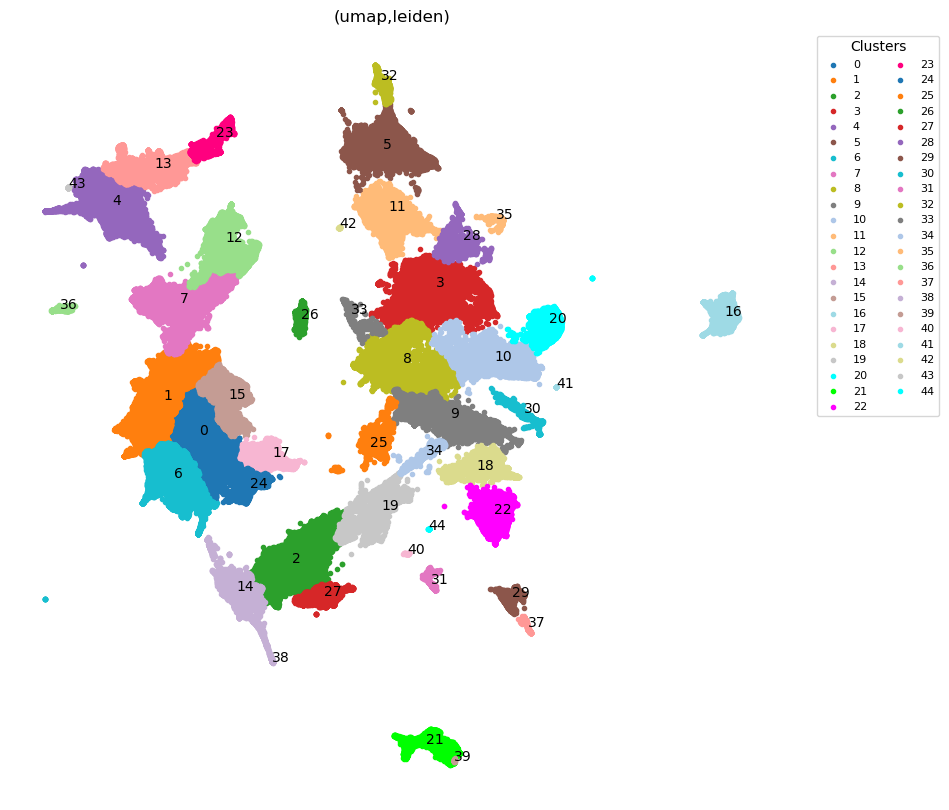

In [177]:
#plot les clusters

clusterer_dir_name = get_reducer_dir_name(cluster_params, reducer_dir_name)
chemin = f'./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/niches/results_niche/{reducer_dir_name}/{clusterer_dir_name}/OUTPUT'
save_dir = Path(chemin)
save_dir.mkdir(exist_ok=True)


extra_str = ''

legend_opt = {
    'title': 'Clusters',
    'ncol': 2,
    'fontsize': 8,
    'title_fontsize': 10,
    'bbox_to_anchor': (1.05, 1),
    'loc': 'upper left'
}




# file name du plot après save de la forme =  f'cluster_labels{str_params}{extra_str}.png'
#cluster_params = dic, les paramètres utilisés pour clusterisation,
#  extra_str est ajouté à la fin du nom avant extension en info complémentaire

ax = mosna.plot_clusters(embed_viz = embed_viz, 
                  cluster_labels= labels,
                  save_dir=save_dir,
                  cluster_params=cluster_params_plot,
                  extra_str=extra_str, 
                  legend_opt =legend_opt
             )

fig = ax.get_figure()
ax.set_title(f"({cluster_params['reducer_type']},{cluster_params['clusterer_type']})")


if cluster_params_plot is None:
    str_params = ''
else:
    str_params = '_' + '_'.join([str(key) + '-' + str(val) for key, val in cluster_params_plot.items()])

figname =  f'cluster_labels{str_params}{extra_str}.png'
plt.savefig(save_dir / figname, bbox_inches="tight", dpi=150)

Composition 

In [178]:
#récup les cell types sans calculer si dans fichier

save_dir = Path("./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/niches/agreg")
cell_types = np.load(save_dir / f'cell_types_aggreg_good_order.parquet.npy',allow_pickle=True)



In [179]:
#directory dans lequel save les plots
chemin_save_plot = f'./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/niches/results_niche/{reducer_dir_name}/{clusterer_dir_name}/OUTPUT/'

In [180]:
# je récup la composition des niches,cette fonction  Make a counts matrix of cell types composition of niches.
normalize = ['Total','obs', 'niche','obs&niche','clr']
niches = labels
var = cell_types

#infos pour le plot :

clusterer_dir_name = get_reducer_dir_name(cluster_params, reducer_dir_name)

save_dir = Path(chemin_save_plot)

for normalize in normalize:
    # je récup la composition des niches,cette fonction  Make a counts matrix of cell types composition of niches.
    counts = mosna.make_niches_composition(var = var, niches =niches, normalize = normalize)
    #plot niches Aggregated composition utilise 'counts'

    figsize = None
    plt.figure(figsize=(15,10))
    fig = sns.heatmap(counts, linewidths=.5, cmap=sns.color_palette("Blues", as_cmap=True),
                        xticklabels=True, yticklabels=True)
    fig.set_title('Niches Aggregated composition')
    fig.set_xlabel("Niches")
    fig.set_ylabel("Clusters")

    if cluster_params['clusterer_type'] == 'leiden':
        plt.savefig(save_dir/f"{normalize}_normalization_niches_res_{cluster_params['resolution']}_{cluster_params['clusterer_type']}.png",bbox_inches="tight")
    else : 
        plt.savefig(save_dir/f"{normalize}_normalization_niches_{cluster_params['clusterer_type']}.png",bbox_inches="tight")
    plt.close()

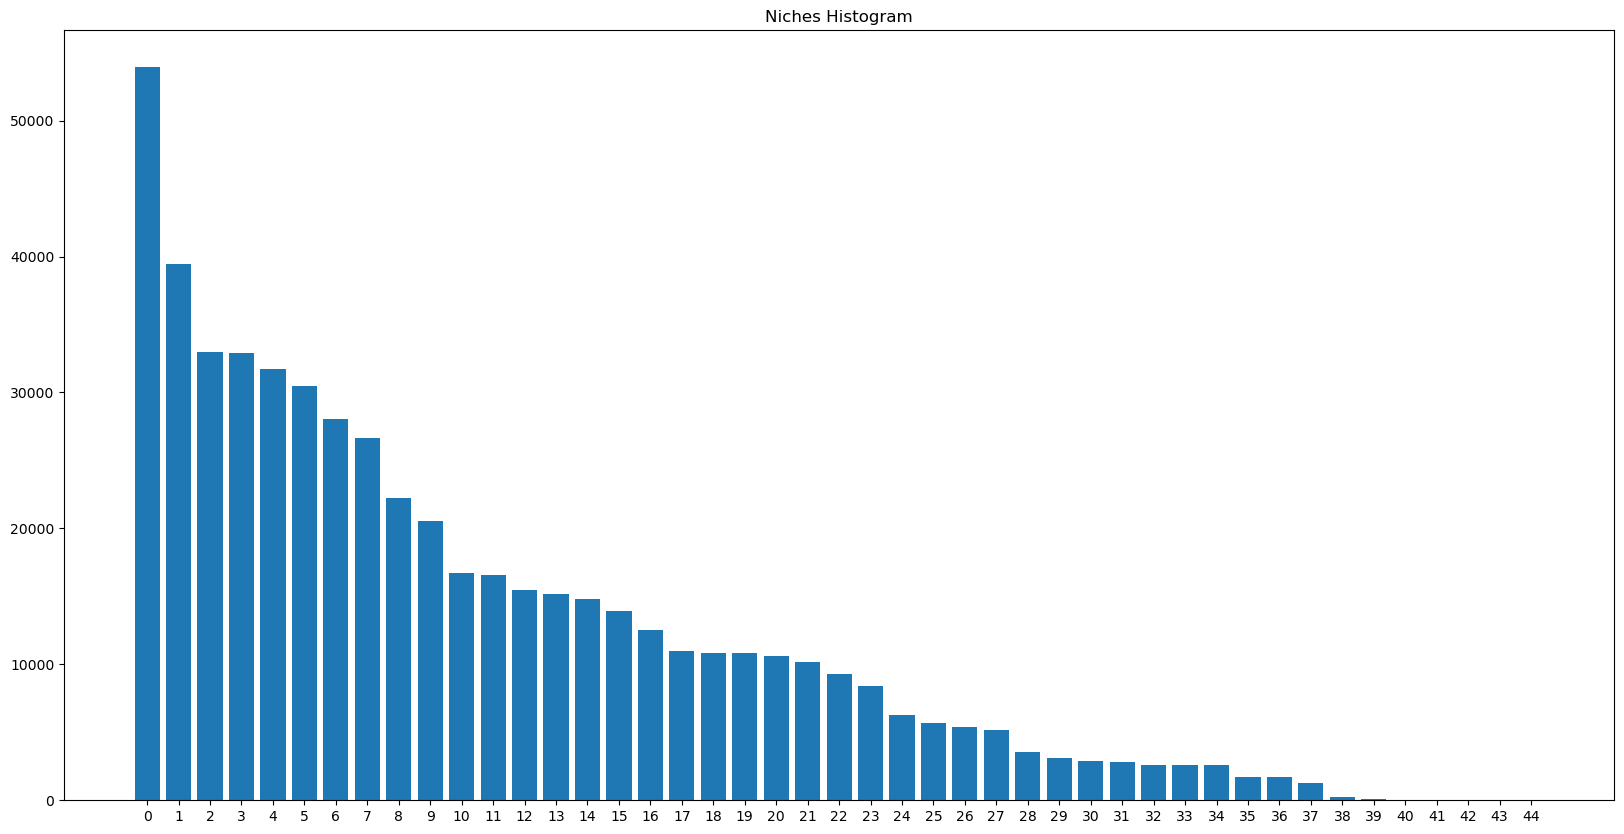

In [181]:
#histogram combien de cell par niche

clusterer_dir_name = get_reducer_dir_name(cluster_params, reducer_dir_name)

save_dir = Path(chemin_save_plot)

figsize =None
fig, ax = plt.subplots(figsize=(20,10))
niche_id, niche_count = np.unique(niches, return_counts=True)
ax.bar(niche_id, niche_count, width=0.8)
ax.set_xticks(niche_id)
ax.set_title('Niches Histogram')

if cluster_params['clusterer_type'] == 'leiden':
    plt.savefig(save_dir/f'niches_res_{cluster_params["resolution"]}__{cluster_params["clusterer_type"]}_histogram.png',bbox_inches="tight")
else : 
    plt.savefig(save_dir/f'niches_{cluster_params["clusterer_type"]}_histogram.png',bbox_inches="tight")


## Cluster merging

In [182]:
#Pour le clustering 



cluster_params = {
    'reducer_type' : 'umap',
   'clusterer_type':'leiden',
   'n_clusters':7,
   'force_recompute' : False,
   'resolution' : 0.05,
   #n_neighbors = neighbors dans umap et k_cluster = neighbors dans kmm
   'n_neighbors' :20,
   'k_cluster' : 15
   #résolution que pour leiden
   
}

reducer_dir_name ='reducer-umap_dim-2_nneigh-20_metric-manhattan_min_dist-0.0'

In [183]:


def get_reducer_dir_name(cluster_params, reducer_dir_name):
    #fonction pour récupérer le nom du dossier cluster
    #cluster_params = dico
    #reducer dir name = str
    if cluster_params["clusterer_type"] == 'leiden':
        k_cluster = str(cluster_params["k_cluster"])
        clusterer_dir_name = f'clusterer-{cluster_params["clusterer_type"]}_n_neighbors-{k_cluster}'
    elif cluster_params["clusterer_type"] == 'spectral' or cluster_params["clusterer_type"] == 'ecg':
        k_cluster = str(cluster_params["k_cluster"])
        clusterer_dir_name = f'clusterer-{cluster_params["clusterer_type"]}_n_neighbors-{k_cluster}'
    else : 
        clusterer_dir_name = f'clusterer-{cluster_params["clusterer_type"]}'
    return clusterer_dir_name

#récupérer un dico avec les params qui vont s'afficher dans nom des fichiers plots

if cluster_params['clusterer_type'] == 'gmm' or cluster_params['clusterer_type'] == 'spectral':
   cluster_params_plot = {
      'clusterer_type': cluster_params['clusterer_type'],
      'n_clusters': cluster_params['n_clusters']
   }  
elif cluster_params['clusterer_type'] == 'leiden':
   cluster_params_plot = {
      'clusterer_type': cluster_params['clusterer_type'],
      'res': str(cluster_params['resolution'])
   }
else:
   cluster_params_plot = {
      'clusterer_type': cluster_params['clusterer_type']
   }


In [184]:
# charger les labels à merger sans recalculer
#file name = nom du fichier avec les labels
clusterer_dir_name = get_reducer_dir_name(cluster_params, reducer_dir_name) 

labels_file_name = 'leiden_resolution-0.05_labels.npy'


chemin = f'./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/niches/results_niche/{reducer_dir_name}/{clusterer_dir_name}/'
chemin = Path(chemin)
labels = np.load(chemin/labels_file_name)

In [193]:

clusters = labels



#charger les embeddings

#charger les embeddings
file_name = 'embedding.npy'
path = Path("./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/niches/results_niche/",reducer_dir_name)
embed_viz = np.load(path/file_name)
embed_viz

#save_dir où enregistrer labels merged
chemin = f'./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/niches/results_niche/{reducer_dir_name}/{clusterer_dir_name}/OUTPUT_merged'
save_dir = Path(chemin)
save_dir.mkdir(exist_ok=True)

relabel_clusters_ids = True
coords = embed_viz
n_neigh_max = 10
cond_n_clust = None
force_n_clust = False


#pour merge cluster
"""
    Merge iteratively the smallest cluster to it's closest cluster 
    if its size is lower than a given size, until no further merging
    occurs or until a condition is reached.

    Parameters
    ----------
    clusters : np.array
        Cluster labels.
    coords : np.ndarray
        Coordinates of points in clusters.
    cond_n_clust: Union[int, None], None
        Sufficient condition on the number of clusters below which the iterative
        merge stops.
    force_n_clust : bool, False
        If True, force merging until the desired number of clusters is reached.
        It overides the 'until no further merging occurs' condition.
    size_thresh : Union[int, None], None
        If provided, the size threshold to merge the smallest cluster.
        If none, computed as the base size * ratio_size
    size_perc : int, 25
        Percentile of cluster size as the base size used for the size threshold.
    ratio_size : float, 0.1
        Ratio to compute size_thresh.
    n_neigh_max : int, 10
        Number of points to consider inside the cluster to merge for the closest neighbor.
    relabel_clusters_ids : bool, True
        If True, relabel N clusters between 0 and N-1.
    verbose : int, 1
        Verbosity level.
    
    Returns
    -------
    clusters : np.array
        Potentially merged clusters.
    """

labels_merged = mosna.merge_clusters_until(
    clusters = clusters,
    coords = coords,
    cond_n_clust = cond_n_clust,
    n_neigh_max =n_neigh_max,
    relabel_clusters_ids = relabel_clusters_ids,
    force_n_clust = force_n_clust,

    )

np.save(save_dir/"labels_merged.npy", labels_merged)


cluster 44 merged with cluster 22
cluster 43 merged with cluster 4
cluster 42 merged with cluster 11
cluster 40 merged with cluster 31
cluster 41 merged with cluster 10
cluster 39 merged with cluster 21
cluster 38 merged with cluster 14
no further merging can occur


In [194]:
#Enregistre (sans dropna) un data frame avec les nodes et leur label niche, index n'est pas set à zéro
#(ici mets les lignes qui recup big nodes, comme ça sera sans colone patient salmple en doukble)

clusterer_dir_name = get_reducer_dir_name(cluster_params, reducer_dir_name)
chemin = f'./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/niches/results_niche/{reducer_dir_name}/{clusterer_dir_name}/OUTPUT_merged'
save_dir = Path(chemin)

folder = Path("./data/nodes_arcsinh_states_labeled/corrected_double_status_tumour_and_macrostates_labeled/leiden_states")
files = folder.glob("nodes_*")




all_dfs = []

for file in files:
    
    if "nodes" not in file.name:
        continue

    if file.suffix == ".csv":
        df = pd.read_csv(file)
    elif file.suffix == ".parquet":
        df = pd.read_parquet(file)
    elif file.suffix in [".xlsx", ".xls"]:
        df = pd.read_excel(file)
    else:
        continue

    df["source_file"] = file.stem
    all_dfs.append(df)



nodes_cluster_labeled = pd.concat(all_dfs, ignore_index=True)

#nodes_cluster_labeled = pd.concat([big_nodes, var_aggreg], axis=1)


#print(nodes_cluster_labeled[['patient','sample','source_file']])
#nodes_cluster_labeled = nodes_cluster_labeled.reset_index()
#supprime les colonnes en dupliqué et garde que premier qu'il rencontre
#nodes_cluster_labeled = nodes_cluster_labeled.loc[:, ~nodes_cluster_labeled.columns.duplicated()]
nodes_cluster_labeled['Niche'] = labels_merged
print(nodes_cluster_labeled[['source_file',"Niche",'Object']])

# crée tous les dossiers parents si besoin
save_dir.mkdir(parents=True, exist_ok=True)

nodes_cluster_labeled.to_parquet(save_dir/f'nodes_cluster_{cluster_params["clusterer_type"]}_labeled.parquet')

                     source_file  Niche  Object
0       nodes_patient-4_sample-1      1       1
1       nodes_patient-4_sample-1      6       2
2       nodes_patient-4_sample-1      6       3
3       nodes_patient-4_sample-1      0       4
4       nodes_patient-4_sample-1      0       5
...                          ...    ...     ...
543082  nodes_patient-1_sample-3      1   11150
543083  nodes_patient-1_sample-3      0   11151
543084  nodes_patient-1_sample-3      1   11152
543085  nodes_patient-1_sample-3      1   11153
543086  nodes_patient-1_sample-3      1   11154

[543087 rows x 3 columns]


In [195]:
# load labels_merged sans charger :
#save_dir où sont enregistrées labels merged
chemin = f'./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/niches/results_niche/{reducer_dir_name}/{clusterer_dir_name}/OUTPUT_merged'
save_dir = Path(chemin)

file_name = 'labels_merged.npy'

labels_merged = np.load(save_dir/file_name)



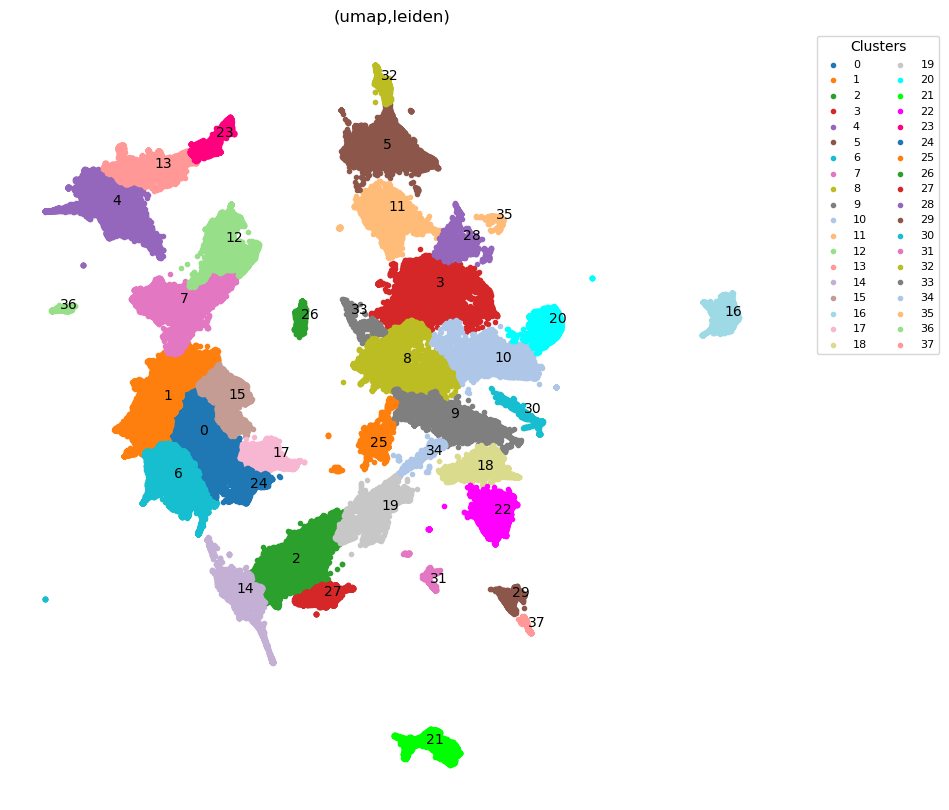

In [196]:

# pour plot
chemin = f'./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/niches/results_niche/{reducer_dir_name}/{clusterer_dir_name}/OUTPUT_merged'
save_dir = Path(chemin)
save_dir.mkdir(exist_ok=True)


extra_str='merged'

legend_opt = {
    'title': 'Clusters',
    'ncol': 2,
    'fontsize': 8,
    'title_fontsize': 10,
    'bbox_to_anchor': (1.05, 1),
    'loc': 'upper left'
}


ax = mosna.plot_clusters(
    embed_viz = embed_viz,
    cluster_labels = labels_merged,
    save_dir = save_dir,
    cluster_params=cluster_params_plot,
    extra_str=extra_str,
    legend_opt = legend_opt
    )
fig = ax.get_figure()
ax.set_title(f"({cluster_params['reducer_type']},{cluster_params['clusterer_type']})")

if cluster_params_plot is None:
    str_params = ''
else:
    str_params = '_' + '_'.join([str(key) + '-' + str(val) for key, val in cluster_params_plot.items()])

figname =  f'cluster_labels{str_params}{extra_str}.png'
plt.savefig(save_dir / figname, bbox_inches="tight", dpi=150)

In [197]:
#récup les cell types sans calculer si dans fichier

save_dir_cell_types = Path("./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/niches/agreg")
cell_types = np.load(save_dir_cell_types / f'cell_types_aggreg_good_order.parquet.npy',allow_pickle=True)

In [198]:
chemin_save_plot = f'./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/niches/results_niche/{reducer_dir_name}/{clusterer_dir_name}/OUTPUT_merged'

In [199]:
# je récup la composition des niches,cette fonction  Make a counts matrix of cell types composition of niches.
normalize = ['Total','obs', 'niche','obs&niche','clr']
niches = labels_merged
var = cell_types

#infos pour le plot :

clusterer_dir_name = get_reducer_dir_name(cluster_params, reducer_dir_name)

save_dir = Path(chemin_save_plot)

for normalize in normalize:
    # je récup la composition des niches,cette fonction  Make a counts matrix of cell types composition of niches.
    counts = mosna.make_niches_composition(var = var, niches =niches, normalize = normalize)
    #plot niches Aggregated composition utilise 'counts'

    figsize = None
    plt.figure(figsize=(15,10))
    fig = sns.heatmap(counts, linewidths=.5, cmap=sns.color_palette("Blues", as_cmap=True),
                        xticklabels=True, yticklabels=True)
    fig.set_title('Niches Aggregated composition')
    fig.set_xlabel("Niches")
    fig.set_ylabel("Clusters")

    if cluster_params['clusterer_type'] == 'leiden':
        plt.savefig(save_dir/f"{normalize}_normalization_niches_res_{cluster_params['resolution']}_{cluster_params['clusterer_type']}.png")
    else : 
        plt.savefig(save_dir/f"{normalize}_normalization_niches_{cluster_params['clusterer_type']}.png")
    plt.close()

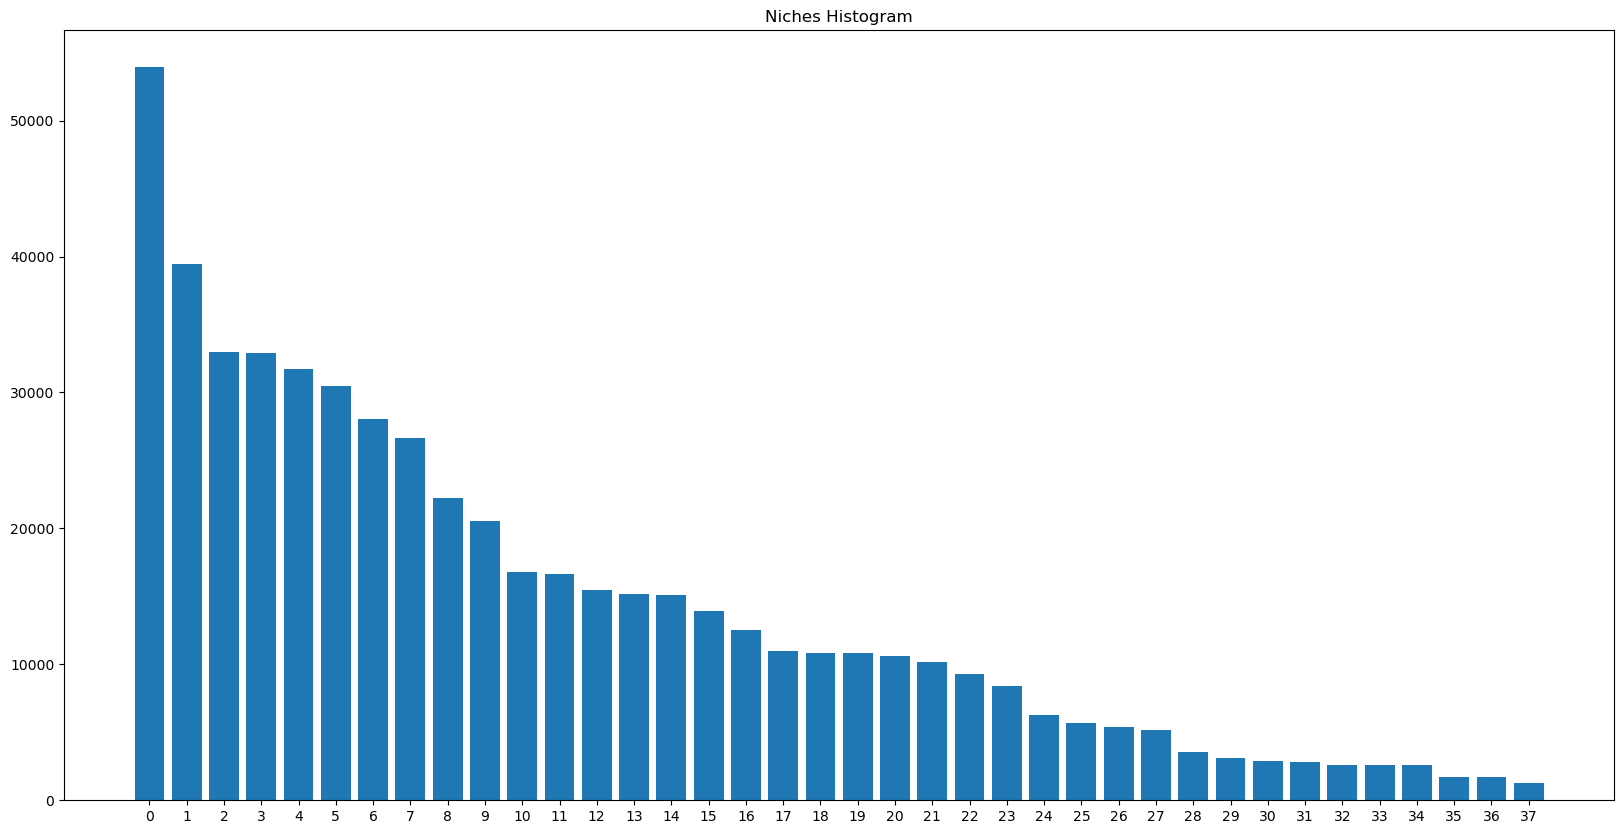

In [200]:
#histogram combien de cell par niche

clusterer_dir_name = get_reducer_dir_name(cluster_params, reducer_dir_name)

save_dir = Path(chemin_save_plot)

figsize =None
fig, ax = plt.subplots(figsize=(20,10))
niche_id, niche_count = np.unique(niches, return_counts=True)
ax.bar(niche_id, niche_count, width=0.8)
ax.set_xticks(niche_id)
ax.set_title('Niches Histogram')

if cluster_params['clusterer_type'] == 'leiden':
    plt.savefig(save_dir/f'niches_res_{cluster_params["resolution"]}__{cluster_params["clusterer_type"]}_histogram.png',bbox_inches="tight")
else : 
    plt.savefig(save_dir/f'niches_{cluster_params["clusterer_type"]}_histogram.png',bbox_inches="tight")
